# Count the number of colocalization points in the Mediterranean sea

- Should be under SWOT swath during the fast sampling period

In [4]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir
from swot import browse_swot_250#, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

_______
# SWOT

In [5]:
dfs = browse_swot_250().reset_index()
dfs

,day,pass_number,cycle_number,file,time,start_time_cut,end_time_cut
0,2023-04-01,3,478,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-01 23:42:32.696536000,2023-04-01 11:47:13.760762624,2023-04-02 11:37:51.561104544
1,2023-04-02,3,479,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-02 23:33:10.425673088,2023-04-02 11:37:51.561104544,2023-04-03 11:28:29.307429408
2,2023-04-03,3,480,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-03 23:23:48.189185728,2023-04-03 11:28:29.307429408,2023-04-04 11:19:07.046608544
3,2023-04-04,3,481,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-04 23:14:25.904031360,2023-04-04 11:19:07.046608544,2023-04-05 11:09:44.780262144
4,2023-04-05,3,482,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-05 23:05:03.656492928,2023-04-05 11:09:44.780262144,2023-04-06 11:00:22.763027360
...,...,...,...,...,...,...,...
182,2023-07-05,16,573,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-05 19:33:50.331633280,2023-07-05 07:38:31.368841152,2023-07-06 07:29:09.302501440
183,2023-07-06,16,574,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-06 19:24:28.273369600,2023-07-06 07:29:09.302501440,2023-07-07 07:19:47.209324384
184,2023-07-07,16,575,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-07 19:15:06.145279168,2023-07-07 07:19:47.209324384,2023-07-08 07:10:25.074586176
185,2023-07-08,16,576,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-08 19:05:44.003893184,2023-07-08 07:10:25.074586176,2023-07-09 07:01:02.936174400


In [59]:
import geopandas as gpd
import shapely as shp
from shapely.geometry import Polygon

def build_swath_polygon(da, x="x", y="y", dix = 50, diy = 50, side=None):
    """ build a shapely polygon of swot swath

    Parameters
    ----------
    da: xr.Dataset, xr.DataArray
        Input dataset where coordinates x/y are found
    x, y: str, optional
        Coordinates to use to define bounds
    dix, diy: int, optional
        Subsampling steps in num_pixels and num_lines directions
    side: str, optional
        take either the polygon for the full swath, or the right/left ones
    """

    # right swath
    if side=="left":
        da = da.isel(num_pixels=slice(0, 237))
    elif side=="right":
        da = da.isel(num_pixels=slice(282, -1))
            
    nx = da.num_pixels.size
    ny = da.num_lines.size
        
    rg = lambda size, di: list(range(0, size, di))+[size-1]
    
    X, Y = [], []
    
    e = da.isel(num_lines=0, num_pixels=rg(nx, dix))
    X += list(e[x].data)
    Y += list(e[y].data)

    e = da.isel(num_lines=rg(ny,diy), num_pixels=-1)
    X += list(e[x].data)
    Y += list(e[y].data)
    
    e = da.isel(num_lines=-1, num_pixels=rg(nx, dix))
    X += list(e[x].data[::-1])
    Y += list(e[y].data[::-1])
    
    e = da.isel(num_lines=rg(ny,diy), num_pixels=0)
    X += list(e[x].data[::-1])
    Y += list(e[y].data[::-1])
    
    #mpt = shp.MultiPoint([[x, y] for x, y in zip(X, Y)])
    #poly = mpt.convex_hull
    poly = shp.Polygon([[x, y] for x, y in zip(X, Y)])

    return poly, X, Y

def add_mask_inside_swot(ds_swot, ds_drifters, dix = 50, diy = 50):
    # build swath polygons
    #both = build_swath_polygon(swot, x="longitude", y="latitude", dix = 50, diy = 50, side=None)
    left = build_swath_polygon(ds_swot, x="longitude", y="latitude", dix=dix, diy=diy, side="left")[0]
    right = build_swath_polygon(ds_swot, x="longitude", y="latitude", dix=dix, diy=diy, side="right")[0]
    Xl, Yl = build_swath_polygon(ds_swot, x="longitude", y="latitude", dix=dix, diy=diy, side="left")[1:]
    Xr, Yr = build_swath_polygon(ds_swot, x="longitude", y="latitude", dix=dix, diy=diy, side="right")[1:]
    
    # stack dimensions
    drs = ds_drifters.stack(points=("datetime", "drifter_id"))
    lon, lat = drs.longitude.fillna(0.).values, drs.latitude.fillna(0.).values
    # test if points inside right swath
    drs["inside_right"] = (
        "points", 
        np.array([right.contains(shp.Point(_lon, _lat)) for _lon, _lat in zip(lon, lat)]),
    )
    # test if points inside left swath
    drs["inside_left"] = (
        "points", 
        np.array([left.contains(shp.Point(_lon, _lat)) for _lon, _lat in zip(lon, lat)]),
    )
    # put mask inside original dataset
    ds_drifters["inside_left"] = drs["inside_left"].unstack()
    ds_drifters["inside_right"] = drs["inside_right"].unstack()
    return ds_drifters, Xl, Yl, Xr, Yr, left, right

In [54]:
shp.Polygon?

Init signature: shp.Polygon(shell=None, holes=None)
Docstring:     
A geometry type representing an area that is enclosed by a linear ring.

A polygon is a two-dimensional feature and has a non-zero area. It may
have one or more negative-space "holes" which are also bounded by linear
rings. If any rings cross each other, the feature is invalid and
operations on it may fail.

Parameters
----------
shell : sequence
    A sequence of (x, y [,z]) numeric coordinate pairs or triples, or
    an array-like with shape (N, 2) or (N, 3).
    Also can be a sequence of Point objects.
holes : sequence
    A sequence of objects which satisfy the same requirements as the
    shell parameters above

Attributes
----------
exterior : LinearRing
    The ring which bounds the positive space of the polygon.
interiors : sequence
    A sequence of rings which bound all existing holes.

Examples
--------
Create a square polygon with no holes

>>> coords = ((0., 0.), (0., 1.), (1., 1.), (1., 0.), (0., 0.))
>>>

In [26]:
def select_data(cycle, swath, dfs):
    # SWOT
    df = dfs.where(dfs.pass_number==int(swath)).dropna()
    dss = xr.open_dataset(df.set_index('cycle_number').loc[cycle].file)
    dss['num_lines']=np.arange(len(dss.num_lines))
    dss['num_pixels']=np.arange(len(dss.num_pixels))
    
    dss['eta'] = dss.cvl_mean_dynamic_topography_cnes_cls_22 + dss.cvl_ocean_tide_fes_2022 + dss.duacs_ssha_karin_2_filtered
    dss.eta.attrs={'long_name':'ADT+ocean tide correction', 'unit':'m'}

    # DRIFTERS
    time = pd.to_datetime(dss.time.mean().values).round('min')
    #dt = pd.Timedelta('12h')#drifters points for whose the SWOT images is the nearest one (less precise)
    dt = df.time.diff().median() #drifters points for whose the SWOT images is the nearest one (more precise)
    dr = xr.open_dataset(os.path.join(drifters_dir,'L2', 'all_med_variational_10min_v0.nc'))
    dr= dr.isel(drifter_id = slice(0,2))#only 2
    dr_key = dr[['cruise_id', 'drifter_type']]
    dr = dr.where(dr.gap_mask==1)
    # Time selection
    dr_=dr
    #dr_ = dr.sel(datetime = slice(time-dt, time+dt))
    # Under inside SWOT 
    dr_, Xl, Yl, Xr, Yr, left, right = add_mask_inside_swot(dss, dr_)
    dr__ = dr_.where(dr_["inside_left"]+dr_["inside_right"])

    
    return dss, dr__, dr_key, Xl, Yl, Xr, Yr, left, right

In [12]:
dss, dr_, dr_key, Xl, Yl, Xr, Yr, left, right = select_data(500, 3, dfs)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


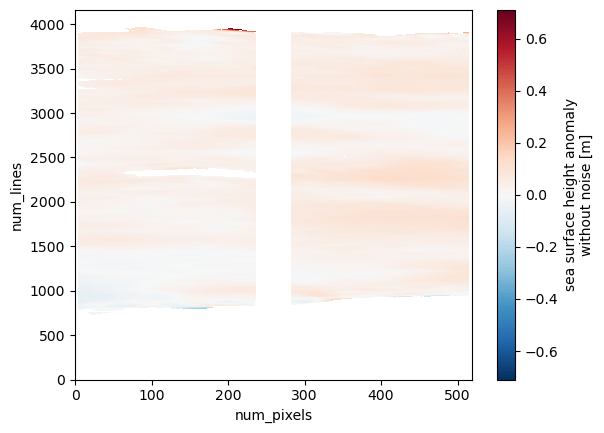

In [15]:
dss.duacs_ssha_karin_2_filtered.plot()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/si

Text(0.5, 1.0, 'Swath n°3, Cycle n°479\n04-02-2023 23:34')

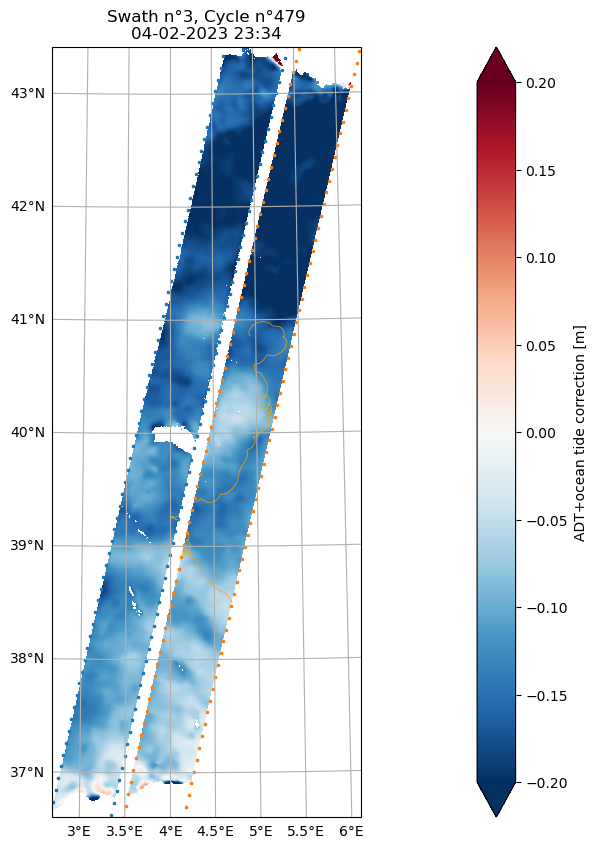

In [60]:
lon=4
lat=39.3

cycle=479#520
swath=3
dss, dr, dr_key, Xl, Yl, Xr, Yr, left, right= select_data(cycle, swath, dfs)
#dr=dr_
if swath == 3 : 
    bbox = [2.7, 6.1, 36.6, 43.4]
    #bbox = [3.5, 6.1, 40, 43.4]
    vmax=0.2
    vmin=-0.2

if swath == 16 : 
    #bbox = [0.9, 3.7, 36.5, 41.5]
    bbox = [0.9, 3.7, 38, 41.5]
    vmax=0.2
    vmin=-0.2

fig = plt.figure(figsize=(10,10))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(lon, lat))

dss.eta.plot(x='longitude', y='latitude', transform=crs, ax=ax, 
             vmin=vmin, 
             vmax=vmax,
             cmap='RdBu_r',
             cbar_kwargs={"pad": 0.15}
            )

for id in dr.drifter_id : 
    dr_ = dr.sel(drifter_id=id)
    key = str(dr_key.sel(drifter_id=id)['cruise_id'].values)+': '+str(dr_key.sel(drifter_id=id)['drifter_type'].values)
    if dr_.longitude.dropna('datetime').size==0:
        continue
    else :
        ax.plot(dr_.longitude, dr_.latitude, transform=crs, c='orange', lw=0.5)
        #ax.plot(dr_.longitude.dropna('datetime')[-1], dr_.latitude.dropna('datetime')[-1], marker='x', markersize=3, transform=crs, c='orange', lw=0.5)
        #ax.plot(dr_.longitude, dr_.latitude, transform=crs, c=color[key], label=key, lw=0.5)
ax.scatter(Xl, Yl, marker='x', s=3, transform=crs,)
ax.scatter(Xr, Yr, marker='x', s=3, transform=crs,)


#ax.add_feature(cfeature.LAND,)
ax.set_extent(bbox)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False

time = pd.to_datetime(dss.time.mean().values).round('min')
ax.set_title(f'Swath n°{swath}, Cycle n°{cycle}'+'\n'+f'{time.strftime("%m-%d-%Y %H:%M")}')
#hand, lab = set_legend(handles, labels)
#ax.legend(hand, lab)
#fig.tight_layout()


In [28]:
lont, latt = 5.51, 41


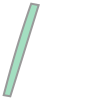

In [29]:
right

In [39]:
right.contains(shp.Point(5.58, 41))

True

In [43]:
p = shp.Point(5.55, 41)
p.within(right)

True

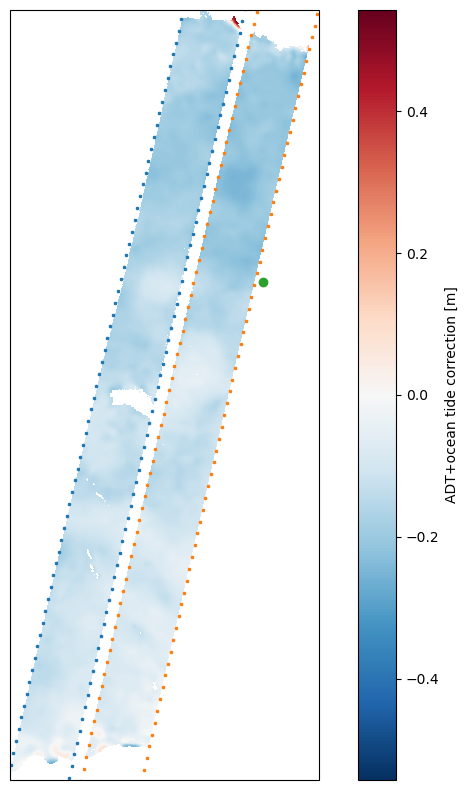

In [57]:
fig = plt.figure(figsize=(10,10))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(lon, lat))

dss.eta.plot(x='longitude', y='latitude',ax=ax, transform=crs,)
ax.scatter(Xl, Yl, marker='x', s=3, transform=crs,)
ax.scatter(Xr, Yr, marker='x', s=3, transform=crs,)
ax.scatter(5.58, 41, transform=crs,)
ax.set_extent(bbox)

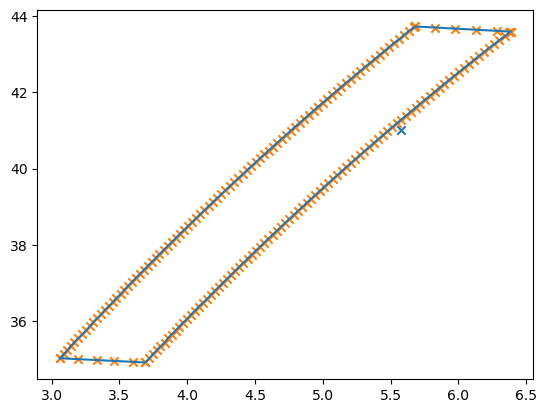

In [61]:
import matplotlib.pyplot as plt

x,y = right.exterior.xy
plt.plot(x,y)
plt.scatter(5.58, 41, marker='x')
plt.scatter(Xr, Yr, marker='x')